In [69]:
from dotenv import load_dotenv
load_dotenv()

True

In [70]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START,END
from langchain_groq import ChatGroq
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal



In [71]:
class MailState(BaseModel):
    query:str = ""
    draft:str = ""
    human_feedback:str = ""
    final_response:str = ""

In [72]:
llm = ChatGroq(model="llama-3.3-70b-versatile")


In [73]:
def DraftEmail(state:MailState) -> MailState:
    if state.human_feedback:
        draft = llm.invoke(f"""
                            Re-write this draft email for {state.query},
                            You have generated this draft email: {state.draft},
                            Human Feedback to apply: {state.human_feedback}
                            """).content
    else:
        draft = llm.invoke(state.query).content

    state.draft = draft
    return state


def HumanFeedback(state:MailState)  -> MailState:
    feedback = interrupt({
        "draft_email":state.draft,
        "question":"Do you want to continue or re-write the mail. "
    })

    fb = (feedback or "").strip().lower()
    if fb in ("approved", "ok", "yes"):
        state.human_feedback = ""
        return state
    else:
        state.human_feedback = feedback
        return state


def FinalNode(state:MailState) -> MailState:
    if state.human_feedback:
        state.final_response = state.human_feedback
        return state
    else:
        print("Email Sent Successfully....")
        state.final_response = "Emil Send Successfully"
        return state    

def ConditionRouting(state:MailState) -> Literal["draft","final"]:
    if state.human_feedback:
        return "draft"
    return "final"
    



In [74]:
graph_builder = StateGraph(MailState)

#### NODES

graph_builder.add_node("draft",DraftEmail )
graph_builder.add_node("human_feedback", HumanFeedback)
graph_builder.add_node("final", FinalNode)

### AGES
graph_builder.add_edge(START, "draft")
graph_builder.add_edge("draft", "human_feedback")
graph_builder.add_conditional_edges("human_feedback",ConditionRouting)
graph_builder.add_edge("final", END)

graph = graph_builder.compile(checkpointer=InMemorySaver())

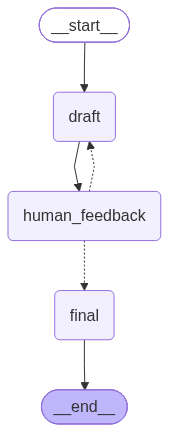

In [75]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [76]:
config = {"configurable": {"thread_id":"1"}}
res = graph.invoke({"query":"I want to send a Email for medical leave request dates will be 02 JUne to 05 June, so creat a simple mail."}, 
                   config = config)

In [77]:
res = graph.invoke(Command(resume="I want to change the leave dates, and new dates are 4 june to 7 june and i want to remove placeholders and just say thankyou"), config=config)

In [78]:
res

{'query': 'I want to send a Email for medical leave request dates will be 02 JUne to 05 June, so creat a simple mail.',
 'draft': 'Here is the revised email:\n\nSubject: Medical Leave Request from 4 June to 7 June\n\nDear Supervisor,\n\nI am writing to request a medical leave of absence from 4 June to 7 June due to a medical condition that requires my attention. I will be unavailable to work during this period and will make sure to catch up on any missed work upon my return.\n\nIf there are any pressing matters that need my attention before my leave, please let me know as soon as possible. I will do my best to ensure a smooth transition of tasks during my absence.\n\nThank you\n\nNote: I have removed the placeholders, changed the leave dates to 4 June to 7 June, and simplified the closing to just "Thank you". Let me know if you need any further changes!',
 'human_feedback': 'I want to change the leave dates, and new dates are 4 june to 7 june and i want to remove placeholders and just 

In [79]:
print(res["draft"])

Here is the revised email:

Subject: Medical Leave Request from 4 June to 7 June

Dear Supervisor,

I am writing to request a medical leave of absence from 4 June to 7 June due to a medical condition that requires my attention. I will be unavailable to work during this period and will make sure to catch up on any missed work upon my return.

If there are any pressing matters that need my attention before my leave, please let me know as soon as possible. I will do my best to ensure a smooth transition of tasks during my absence.

Thank you

Note: I have removed the placeholders, changed the leave dates to 4 June to 7 June, and simplified the closing to just "Thank you". Let me know if you need any further changes!


In [80]:
res

{'query': 'I want to send a Email for medical leave request dates will be 02 JUne to 05 June, so creat a simple mail.',
 'draft': 'Here is the revised email:\n\nSubject: Medical Leave Request from 4 June to 7 June\n\nDear Supervisor,\n\nI am writing to request a medical leave of absence from 4 June to 7 June due to a medical condition that requires my attention. I will be unavailable to work during this period and will make sure to catch up on any missed work upon my return.\n\nIf there are any pressing matters that need my attention before my leave, please let me know as soon as possible. I will do my best to ensure a smooth transition of tasks during my absence.\n\nThank you\n\nNote: I have removed the placeholders, changed the leave dates to 4 June to 7 June, and simplified the closing to just "Thank you". Let me know if you need any further changes!',
 'human_feedback': 'I want to change the leave dates, and new dates are 4 june to 7 june and i want to remove placeholders and just 

In [81]:
res = graph.invoke(Command(resume="Yes"), config=config)

Email Sent Successfully....
